In [233]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import PIL as Image

In [234]:
transform_opt=torchvision.transforms.Compose([transforms.ToTensor()])

In [235]:
train_data = torchvision.datasets.MNIST(root="./dataset",train=True, download=True, transform=transform_opt)
val_data=torchvision.datasets.MNIST(root="./dataset",train=False, download=True, transform=transform_opt)

In [236]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./dataset
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [237]:
val_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./dataset
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [238]:
num_classes=10
batch_size=64
num_channels=1
img_size=28
patch_size=7
num_patches=(img_size//patch_size)**2
emb_dim=64
attention_heads=8
transformer_block=4
learning_rate=0.001
epochs=5
mlp_hidden_nodes=128
dropout=0.1

In [239]:
from torch.utils.data import dataloader
train_loader=dataloader.DataLoader(train_data,batch_size=batch_size,shuffle=True)
val_loader=dataloader.DataLoader(val_data,batch_size=batch_size,shuffle=True)

In [240]:
data_point,label=next(iter(train_loader))
print(f"Image shape after converted to  tensors:{data_point.shape}")
patch_embedding=nn.Conv2d(num_channels,emb_dim,kernel_size=patch_size,stride=patch_size)
x=patch_embedding(data_point)
print(f"Image shape after patch embedding:{x.shape}")

Image shape after converted to  tensors:torch.Size([64, 1, 28, 28])
Image shape after patch embedding:torch.Size([64, 64, 4, 4])


In [241]:
patch_embd_output_flatten=x.flatten(2)
print(patch_embd_output_flatten.shape)
print(patch_embd_output_flatten.transpose(1,2).shape)

torch.Size([64, 64, 16])
torch.Size([64, 16, 64])


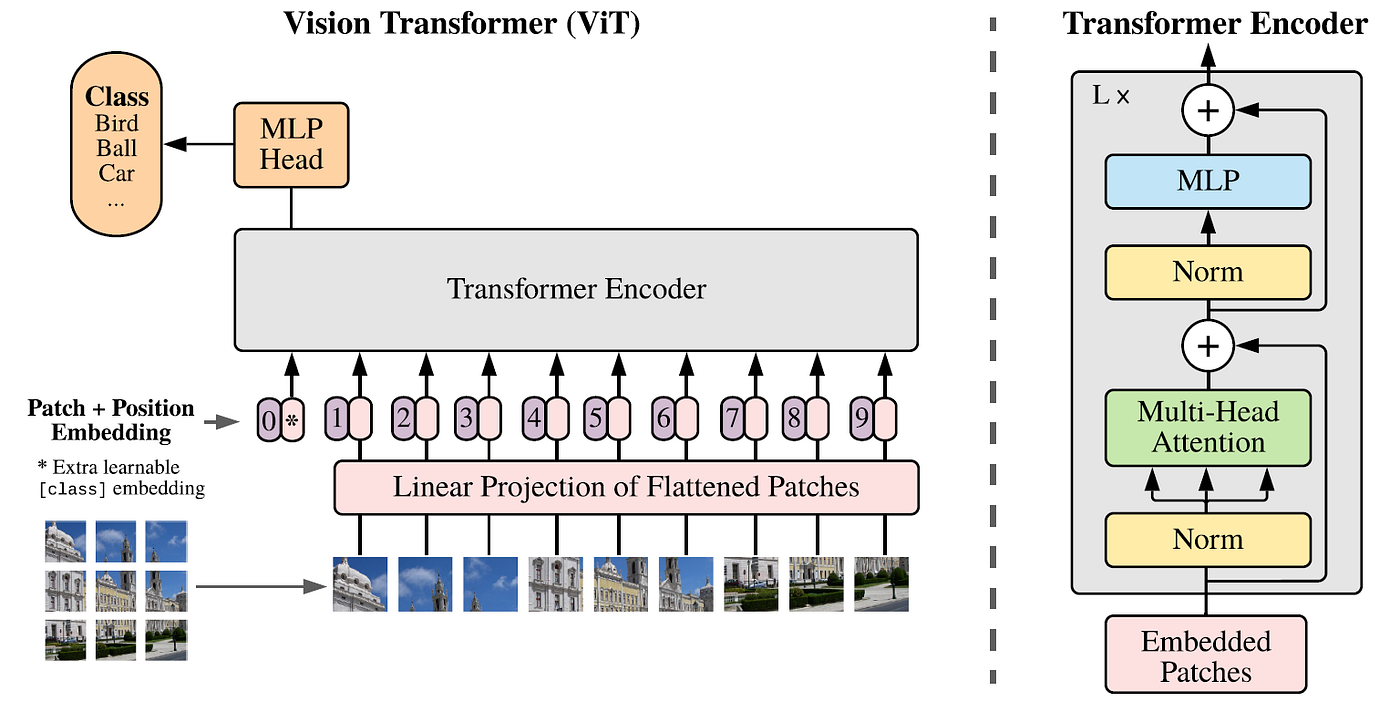

In [242]:
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding=nn.Conv2d(num_channels,emb_dim,kernel_size=patch_size,stride=patch_size)


  def forward(self,x):
    x=self.patch_embedding(x)
    x=x.flatten(2)
    x=x.transpose(1,2)
    return x

In [243]:
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1=nn.LayerNorm(emb_dim)
    self.layer_norm2=nn.LayerNorm(emb_dim)
    self.attention=nn.MultiheadAttention(emb_dim,num_heads=attention_heads,batch_first=True)
    self.MLP=nn.Sequential(
        nn.Linear(emb_dim,mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes,emb_dim),
    )



  def forward(self,x):
    residual1=x
    x=self.layer_norm1(x)
    x=self.attention(x,x,x)[0]
    x=x+residual1

    residual2=self.layer_norm2(x)
    x=self.MLP(x)
    x=x+residual2
    return x

In [244]:
class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1=nn.LayerNorm(emb_dim)
    self.mlp_head=nn.Linear(emb_dim,num_classes)


  def forward(self,x):
    x=self.layer_norm1(x)
    x=self.mlp_head(x)
    return x



In [245]:
class ViT(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding=PatchEmbedding()
    self.cls_token=nn.Parameter(torch.randn(1,1,emb_dim))
    self.pos_emb=nn.Parameter(torch.randn(1,1+num_patches,emb_dim))
    self.transformer_encoder=TransformerEncoder()
    self.transformer_blocks=nn.Sequential(
        *[TransformerEncoder() for _ in range(transformer_block)]
    )
    self.mlp_head=MLP_head()



  def forward(self,x):
    x= self.patch_embedding(x)
    B=x.shape[0]
    class_token=self.cls_token.expand(B,-1,-1)
    x=torch.cat((class_token,x),dim=1)
    x=x+self.pos_emb
    x=self.transformer_encoder(x)
    x=self.transformer_blocks(x)
    x=x[:,0]
    x=self.mlp_head(x)
    return x

In [246]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=ViT().to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
criterion=nn.CrossEntropyLoss()

In [248]:
total_epoch = 0 # Initialize total_epoch outside the epoch loop
for epoch in range(epochs):
  model.train()
  total_loss=0
  correct_epoch=0
  total_samples_epoch = 0 # Reset total_samples for current epoch
  correct_predictions_epoch = 0 # Reset correct_predictions for current epoch
  print(f"Epoch {epoch+1}")
  for batch_idx,(data,targets) in enumerate(train_loader):
    data, targets = data.to(device), targets.to(device) # Corrected variable names

    optimizer.zero_grad()
    outputs = model(data) # Get model outputs
    loss = criterion(outputs, targets) # Calculate loss
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
    preds=outputs.argmax(dim=1)
    correct=(preds==targets).sum().item() # Use targets instead of labels
    correct_predictions_epoch+=correct  # Accumulate correct predictions for current epoch
    total_samples_epoch+=targets.size(0) # Accumulate total samples for current epoch
    accuracy = 100 * correct / targets.size(0) # Calculate accuracy for the batch

    if batch_idx % 100 == 0:
      print(f"Batch {batch_idx+1:3d}, Loss: {loss.item():.4f},{accuracy:.2f}%")

  epoch_accr=100*correct_predictions_epoch/total_samples_epoch # Calculate accuracy for current epoch
  print(f"==>Epoch:{epoch+1},Summary:Total={total_loss:.4f},Accuracy:{epoch_accr:.2f}")

Epoch 1
Batch   1, Loss: 0.0529,98.44%
Batch 101, Loss: 0.1011,95.31%
Batch 201, Loss: 0.0788,96.88%
Batch 301, Loss: 0.0339,100.00%
Batch 401, Loss: 0.0567,100.00%
Batch 501, Loss: 0.0556,98.44%
Batch 601, Loss: 0.1280,98.44%
Batch 701, Loss: 0.0437,98.44%
Batch 801, Loss: 0.0348,98.44%
Batch 901, Loss: 0.0580,96.88%
==>Epoch:1,Summary:Total=85.2524,Accuracy:97.21
Epoch 2
Batch   1, Loss: 0.0801,96.88%
Batch 101, Loss: 0.0697,96.88%
Batch 201, Loss: 0.0125,100.00%
Batch 301, Loss: 0.0186,100.00%
Batch 401, Loss: 0.0814,96.88%
Batch 501, Loss: 0.0142,100.00%
Batch 601, Loss: 0.0235,100.00%
Batch 701, Loss: 0.0104,100.00%
Batch 801, Loss: 0.1124,95.31%
Batch 901, Loss: 0.0411,98.44%
==>Epoch:2,Summary:Total=71.7167,Accuracy:97.65
Epoch 3
Batch   1, Loss: 0.0067,100.00%
Batch 101, Loss: 0.0186,100.00%
Batch 201, Loss: 0.1131,95.31%
Batch 301, Loss: 0.1913,96.88%
Batch 401, Loss: 0.0973,96.88%
Batch 501, Loss: 0.0958,96.88%
Batch 601, Loss: 0.0864,98.44%
Batch 701, Loss: 0.0719,98.44%
Bat

In [250]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images, labels in val_loader:
      images, labels=images.to(device), labels.to(device)
      output=model(images)
      preds=output.argmax(dim=1) # Corrected: use 'output'
      correct+=(preds==labels).sum().item() # Corrected: use '.item()'
      total+=labels.size(0)

  print(f"Accuracy:{100*correct/total:.2f}")

Accuracy:97.62


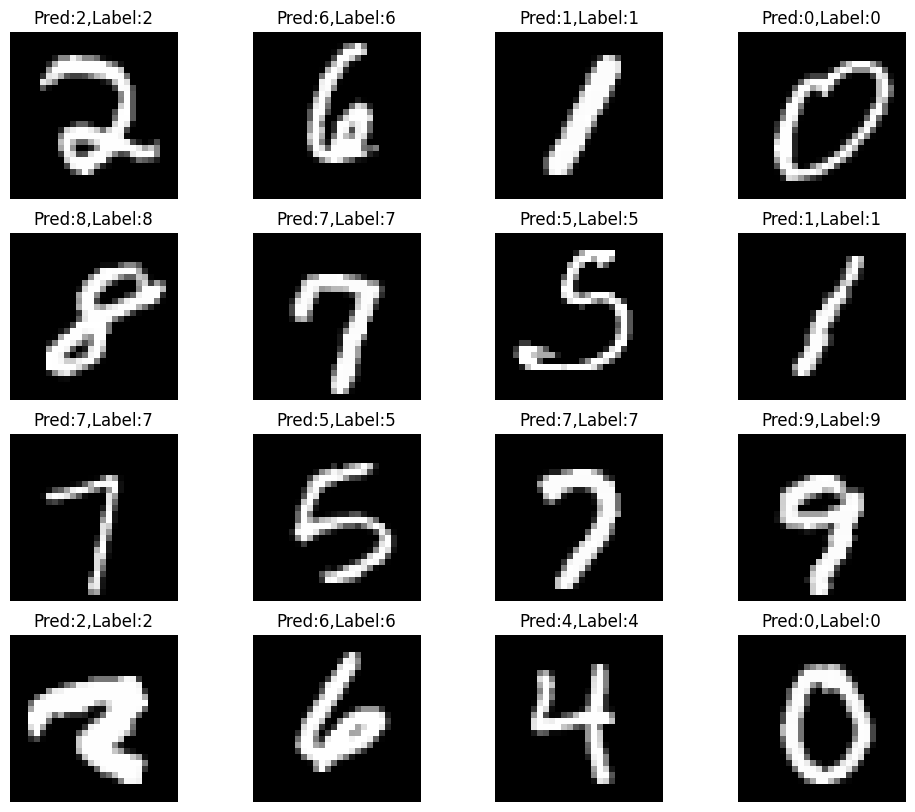

In [254]:
from numpy import imag
import matplotlib.pyplot as plt
model.eval()
images, labels=next(iter(val_loader))
images, labels=images.to(device), labels.to(device)
with torch.no_grad():
  output=model(images)
  preds=output.argmax(dim=1)


  images=images.cpu()
  preds=preds.cpu()
  labels=labels.cpu()

  plt.figure(figsize=(12,10))
  for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(images[i].squeeze(1,2,0),cmap='gray')
    plt.title(f"Pred:{preds[i].item()},Label:{labels[i].item()}")
    plt.axis('off')
  plt.show()



